Missing values: 0

Logistic Regression Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Decision Tree Accuracy: 0.9123
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


Random Forest Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro

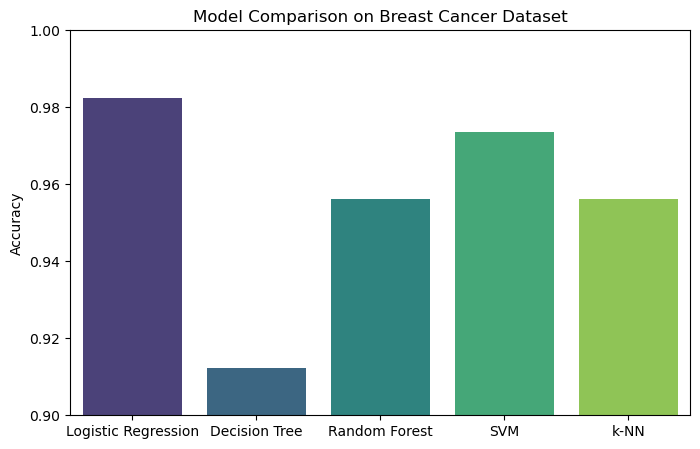

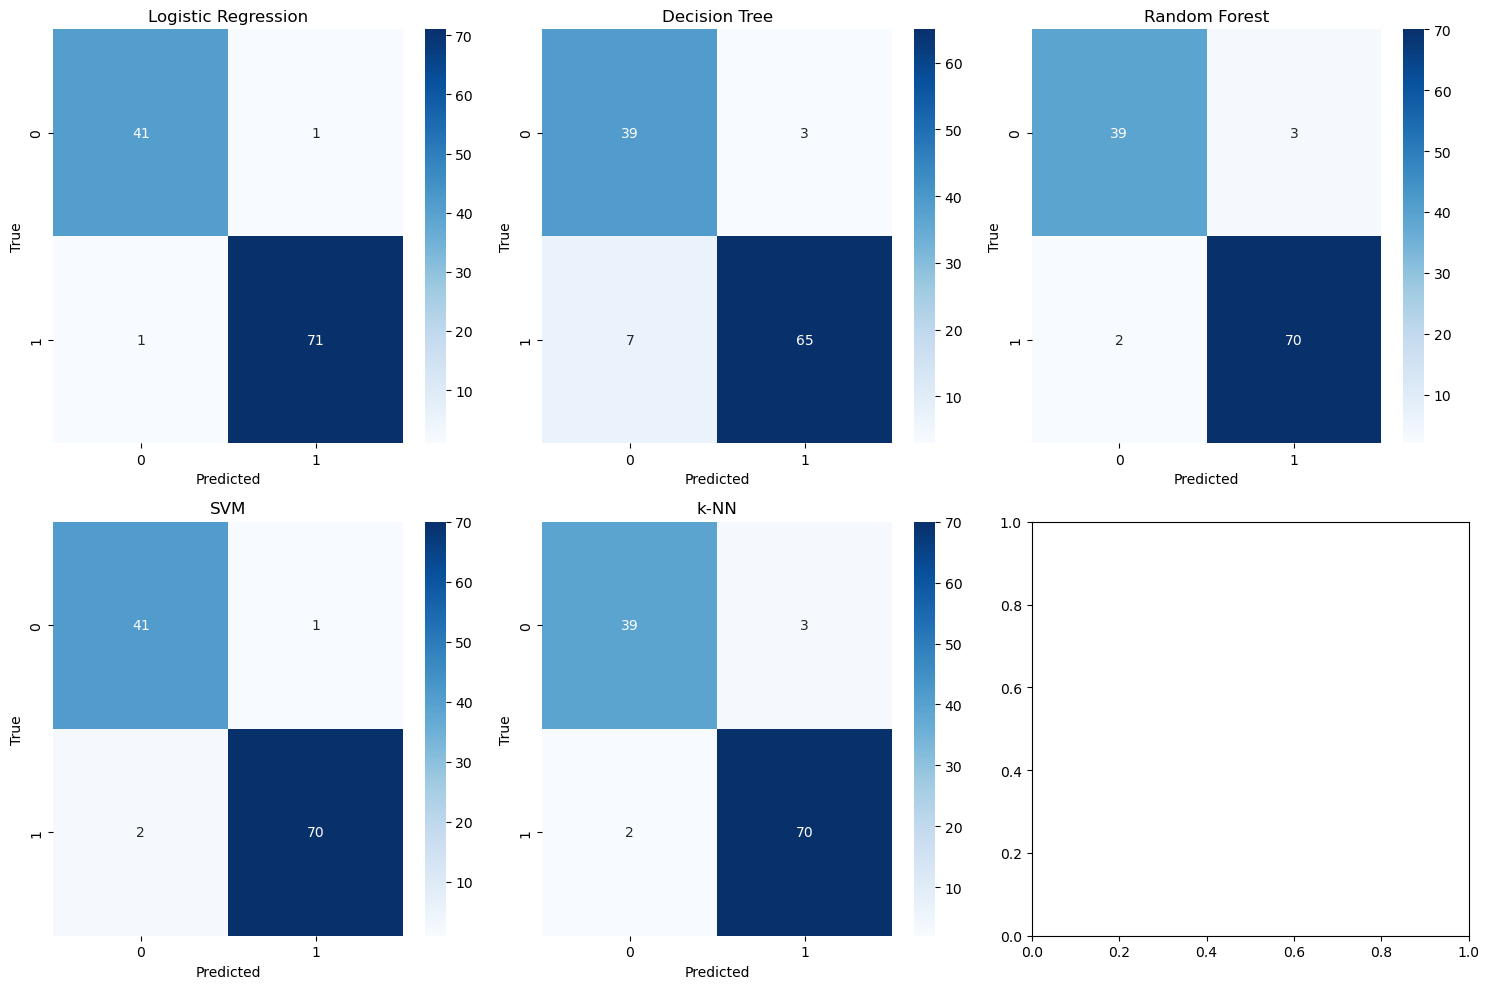


Final Accuracy Comparison:
Logistic Regression: 0.9825
Decision Tree: 0.9123
Random Forest: 0.9561
SVM: 0.9737
k-NN: 0.9561


In [4]:
# Breast Cancer Classification - All in One Cell (Final Version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Step 2: Check missing values
print("Missing values:", X.isnull().sum().sum())

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Define models
log_reg = LogisticRegression(max_iter=5000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
svm = SVC(kernel='linear', probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# Step 6: Fit models
log_reg.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

# Step 7: Evaluate models
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "k-NN": knn
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled if name in ["Logistic Regression", "SVM", "k-NN"] else X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

# Step 8: Compare results visually (fixed Seaborn warning)
plt.figure(figsize=(8,5))
sns.barplot(
    x=list(results.keys()), 
    y=list(results.values()), 
    palette="viridis", 
    hue=list(results.keys()), 
    legend=False
)
plt.ylabel("Accuracy")
plt.title("Model Comparison on Breast Cancer Dataset")
plt.ylim(0.9, 1.0)
plt.show()

#Step 9: Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.ravel()
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled if name in ["Logistic Regression", "SVM", "k-NN"] else X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")
plt.tight_layout()
plt.show()

# Final Results
print("\nFinal Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")
